In [1]:
# import pandas as pd

# df_bolsa_jan = pd.read_csv("202501_NovoBolsaFamilia.csv", sep=';', encoding='latin1')
# df_bolsa_fev = pd.read_csv("202502_NovoBolsaFamilia.csv", sep=';', encoding='latin1') 


In [2]:
# df_bolsa = pd.concat([df_bolsa_jan, df_bolsa_fev], ignore_index=True)

# df_bolsa.shape

# df_bolsa.tail(10)

In [3]:
# df_bolsa.to_parquet("bolsafamilia_202501_202502.parquet", index=False)

In [ ]:
import pandas as pd
import polars as pl
import unidecode
import matplotlib.pyplot as plt
import seaborn as sns

df_bolsapl = pl.read_parquet("bolsafamilia_202501_202502.parquet")

In [5]:
{
    "Shape": df_bolsapl.shape,
    "Head": df_bolsapl.head(10),
    "Tail": df_bolsapl.tail(10)
}


{'Shape': (40810993, 9),
 'Head': shape: (10, 9)
 ┌────────────┬────────────┬─────┬────────────┬───┬────────────┬────────────┬───────────┬───────────┐
 │ MÊS COMPET ┆ MÊS        ┆ UF  ┆ CÓDIGO     ┆ … ┆ CPF        ┆ NIS        ┆ NOME FAVO ┆ VALOR     │
 │ ÊNCIA      ┆ REFERÊNCIA ┆ --- ┆ MUNICÍPIO  ┆   ┆ FAVORECIDO ┆ FAVORECIDO ┆ RECIDO    ┆ PARCELA   │
 │ ---        ┆ ---        ┆ str ┆ SIAFI      ┆   ┆ ---        ┆ ---        ┆ ---       ┆ ---       │
 │ i64        ┆ i64        ┆     ┆ ---        ┆   ┆ str        ┆ f64        ┆ str       ┆ str       │
 │            ┆            ┆     ┆ i64        ┆   ┆            ┆            ┆           ┆           │
 ╞════════════╪════════════╪═════╪════════════╪═══╪════════════╪════════════╪═══════════╪═══════════╡
 │ 202501     ┆ 202308     ┆ SP  ┆ 7071       ┆ … ┆ ***.085.10 ┆ 2.0644e10  ┆ FERNANDA  ┆ 650,00    │
 │            ┆            ┆     ┆            ┆   ┆ 6-**       ┆            ┆ RAMOS     ┆           │
 │            ┆            ┆     

In [6]:
df_bolsapl.columns


['MÊS COMPETÊNCIA',
 'MÊS REFERÊNCIA',
 'UF',
 'CÓDIGO MUNICÍPIO SIAFI',
 'NOME MUNICÍPIO',
 'CPF FAVORECIDO',
 'NIS FAVORECIDO',
 'NOME FAVORECIDO',
 'VALOR PARCELA']

In [7]:
#conversão dos nomes das colunas:

df_bolsapl = df_bolsapl.rename({
    "MÊS COMPETÊNCIA": "mes_competencia",
    "MÊS REFERÊNCIA": "mes_referencia",
    "UF": "uf",
    "CÓDIGO MUNICÍPIO SIAFI": "cod_municipio_siafi",
    "NOME MUNICÍPIO": "nome_municipio",
    "CPF FAVORECIDO": "cpf_favorecido",
    "NIS FAVORECIDO": "nis_favorecido",
    "NOME FAVORECIDO": "nome_favorecido",
    "VALOR PARCELA": "valor_parcela"
})


In [8]:
df_bolsapl.head(10)

mes_competencia,mes_referencia,uf,cod_municipio_siafi,nome_municipio,cpf_favorecido,nis_favorecido,nome_favorecido,valor_parcela
i64,i64,str,i64,str,str,f64,str,str
202501,202308,"""SP""",7071,"""SANTOS""","""***.085.106-**""",2.0644e10,"""FERNANDA RAMOS TEIXEIRA""","""650,00"""
202501,202309,"""SP""",7071,"""SANTOS""","""***.085.106-**""",2.0644e10,"""FERNANDA RAMOS TEIXEIRA""","""650,00"""
202501,202310,"""SP""",7071,"""SANTOS""","""***.085.106-**""",2.0644e10,"""FERNANDA RAMOS TEIXEIRA""","""650,00"""
202501,202311,"""SP""",7071,"""SANTOS""","""***.085.106-**""",2.0644e10,"""FERNANDA RAMOS TEIXEIRA""","""650,00"""
202501,202312,"""SP""",7071,"""SANTOS""","""***.085.106-**""",2.0644e10,"""FERNANDA RAMOS TEIXEIRA""","""650,00"""
202501,202401,"""CE""",1389,"""FORTALEZA""","""***.854.493-**""",1.3024e10,"""IRENICE CAMELO VALETE""","""750,00"""
202501,202401,"""PA""",479,"""LIMOEIRO DO AJURU""","""***.868.792-**""",1.6025e10,"""ANTONIA ELIZANA DA SILVA""","""600,00"""
202501,202401,"""SP""",6313,"""CARAPICUIBA""","""***.972.798-**""",1.3310e10,"""DAMARIS DOS SANTOS OLIVEIRA""","""800,00"""
202501,202401,"""SP""",6313,"""CARAPICUIBA""","""***.696.858-**""",2.0217e10,"""PRISCILA HELENA DE LIMA""","""650,00"""


In [9]:
#conversão da coluna de valor para numero com . ao invés de ,

df_bolsapl = df_bolsapl.with_columns([
    pl.col("valor_parcela")
    .str.replace(",", ".")
    .cast(pl.Float64)
    .alias("valor_parcela")
])

df_bolsapl.select("valor_parcela").head(10)

valor_parcela
f64
650.0
650.0
650.0
650.0
650.0
750.0
600.0
800.0
650.0


In [10]:
df_bolsapl.null_count()


mes_competencia,mes_referencia,uf,cod_municipio_siafi,nome_municipio,cpf_favorecido,nis_favorecido,nome_favorecido,valor_parcela
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,7942467,725,0,0


In [11]:
#descarte da coluna CPF que tem muitos valores nulos

df_bolsapl = df_bolsapl.drop("cpf_favorecido")


In [12]:
#comparação das colunas de mês que podem estar redundantes:

(df_bolsapl.select([
    (pl.col("mes_competencia") != pl.col("mes_referencia")).alias("diferente")
])
.filter(pl.col("diferente") == True)
).height


193687

In [ ]:
#normalizar nomes retirando acentos e espaços para não atrapalhar análises


# função auxiliar para remover acentos:

def normalizar_texto(s):
    if s is not None:
        return unidecode.unidecode(s.strip().lower())
    return s

# aplicar no nome do município:

df_bolsapl = df_bolsapl.with_columns([
    pl.col("nome_municipio").map_elements(normalizar_texto).alias("nome_municipio")
])


C:\Users\Win\AppData\Local\Temp\ipykernel_23324\3950830719.py:14: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  df_bolsapl = df_bolsapl.with_columns([


In [14]:
#garante que a coluna esteja no formato str ao invés de f64: 

df_bolsapl = df_bolsapl.with_columns([
    pl.col("nis_favorecido").cast(pl.Utf8).alias("nis_favorecido")
])

In [15]:
#verificando se existe algum valor não inteiro (que não seja x.0) na coluna:

df_bolsapl.select(
    (pl.col("nis_favorecido")
    .cast(pl.Float64) % 1 != 0)
    .sum()
    .alias("nis_nao_inteiros")
)


nis_nao_inteiros
u32
0


In [16]:
df_bolsapl = df_bolsapl.with_columns([
    pl.col("nis_favorecido")
    .cast(pl.Utf8)
    .str.replace(r"\.0$", "")
    .alias("nis_favorecido")
])

In [17]:
#verificar se existem duplicatas no df:

num_duplicadas = df_bolsapl.shape[0] - df_bolsapl.unique().shape[0]
print(f"Linhas duplicadas: {num_duplicadas}")

Linhas duplicadas: 35


In [18]:
duplicadas = (
    df_bolsapl
    .group_by(df_bolsapl.columns)
    .agg(pl.count().alias("repeticoes"))
    .filter(pl.col("repeticoes") > 1)
)

print(duplicadas)


C:\Users\Win\AppData\Local\Temp\ipykernel_23324\2879834304.py:4: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("repeticoes"))


shape: (24, 9)
┌────────────┬────────────┬─────┬────────────┬───┬────────────┬────────────┬───────────┬───────────┐
│ mes_compet ┆ mes_refere ┆ uf  ┆ cod_munici ┆ … ┆ nis_favore ┆ nome_favor ┆ valor_par ┆ repeticoe │
│ encia      ┆ ncia       ┆ --- ┆ pio_siafi  ┆   ┆ cido       ┆ ecido      ┆ cela      ┆ s         │
│ ---        ┆ ---        ┆ str ┆ ---        ┆   ┆ ---        ┆ ---        ┆ ---       ┆ ---       │
│ i64        ┆ i64        ┆     ┆ i64        ┆   ┆ str        ┆ str        ┆ f64       ┆ u32       │
╞════════════╪════════════╪═════╪════════════╪═══╪════════════╪════════════╪═══════════╪═══════════╡
│ 202502     ┆ 202502     ┆ CE  ┆ 1389       ┆ … ┆ null       ┆ *** BENEFI ┆ 750.0     ┆ 3         │
│            ┆            ┆     ┆            ┆   ┆            ┆ CIÁRIO     ┆           ┆           │
│            ┆            ┆     ┆            ┆   ┆            ┆ MENOR DE   ┆           ┆           │
│            ┆            ┆     ┆            ┆   ┆            ┆ 16 A…      ┆

In [19]:
#ver todas as duplicatas:

duplicadas_todas = df_bolsapl.filter(df_bolsapl.is_duplicated())
print(duplicadas_todas)


shape: (59, 8)
┌─────────────┬─────────────┬─────┬────────────┬────────────┬────────────┬────────────┬────────────┐
│ mes_compete ┆ mes_referen ┆ uf  ┆ cod_munici ┆ nome_munic ┆ nis_favore ┆ nome_favor ┆ valor_parc │
│ ncia        ┆ cia         ┆ --- ┆ pio_siafi  ┆ ipio       ┆ cido       ┆ ecido      ┆ ela        │
│ ---         ┆ ---         ┆ str ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        │
│ i64         ┆ i64         ┆     ┆ i64        ┆ str        ┆ str        ┆ str        ┆ f64        │
╞═════════════╪═════════════╪═════╪════════════╪════════════╪════════════╪════════════╪════════════╡
│ 202501      ┆ 202501      ┆ AM  ┆ 257        ┆ manicore   ┆ null       ┆ *** BENEFI ┆ 750.0      │
│             ┆             ┆     ┆            ┆            ┆            ┆ CIÁRIO     ┆            │
│             ┆             ┆     ┆            ┆            ┆            ┆ MENOR DE   ┆            │
│             ┆             ┆     ┆            ┆            ┆            ┆ 1

In [20]:
#verificar tipo de dados em cada coluna:

list(zip(df_bolsapl.columns, df_bolsapl.dtypes))

[('mes_competencia', Int64),
 ('mes_referencia', Int64),
 ('uf', String),
 ('cod_municipio_siafi', Int64),
 ('nome_municipio', String),
 ('nis_favorecido', String),
 ('nome_favorecido', String),
 ('valor_parcela', Float64)]

In [21]:
#converter 'cod muicipio' para string:

df_bolsapl = df_bolsapl.with_columns(
    pl.col("cod_municipio_siafi").cast(pl.Utf8)
)

In [22]:
#converter datas para formato date e meses abreviados em nome:

# Converter coluna para string
df_bolsapl = df_bolsapl.with_columns(
    pl.col("mes_competencia").cast(pl.Utf8)
)

# Adicionar '01' ao final para representar o primeiro dia do mês
df_bolsapl = df_bolsapl.with_columns(
    (pl.col("mes_competencia") + "01").alias("mes_competencia_str")
)

# Converter para tipo date (formato ano+mês+dia)
df_bolsapl = df_bolsapl.with_columns(
    pl.col("mes_competencia_str").str.strptime(pl.Date, format="%Y%m%d")
)

# Criar nova coluna com mês e ano no formato 'jan 2025'
df_bolsapl = df_bolsapl.with_columns(
    pl.col("mes_competencia_str").dt.strftime("%b %Y").alias("mes_competencia_nome")
)


In [23]:
#agora com 'mes_referencia':

# Converter coluna para string
df_bolsapl = df_bolsapl.with_columns(
    pl.col("mes_referencia").cast(pl.Utf8)
)

# Adicionar '01' ao final para representar o primeiro dia do mês
df_bolsapl = df_bolsapl.with_columns(
    (pl.col("mes_referencia") + "01").alias("mes_referencia_str")
)

# Converter para tipo date (formato ano+mês+dia)
df_bolsapl = df_bolsapl.with_columns(
    pl.col("mes_referencia_str").str.strptime(pl.Date, format="%Y%m%d")
)

# Criar nova coluna com mês e ano no formato 'jan 2025'
df_bolsapl = df_bolsapl.with_columns(
    pl.col("mes_referencia_str").dt.strftime("%b %Y").alias("mes_referencia_nome")
)

In [24]:
# Converter string para float

df_bolsapl = df_bolsapl.with_columns(
    pl.col("valor_parcela").cast(pl.Float64).round(2).alias("valor_parcela")
)


In [25]:
# criar coluna de ano:

df_bolsapl = df_bolsapl.with_columns(
    pl.col("mes_competencia_nome").str.slice(-4, 4).cast(pl.Int32).alias("ano_competencia")
)

In [34]:
df_bolsapl.select('nis_favorecido','nome_favorecido','valor_parcela','cod_municipio_siafi','uf','nome_municipio','mes_competencia_nome','mes_referencia_nome').head(10)

nis_favorecido,nome_favorecido,valor_parcela,cod_municipio_siafi,uf,nome_municipio,mes_competencia_nome,mes_referencia_nome
str,str,f64,str,str,str,str,str
"""20643890445""","""FERNANDA RAMOS TEIXEIRA""",650.0,"""7071""","""SP""","""santos""","""Jan 2025""","""Aug 2023"""
"""20643890445""","""FERNANDA RAMOS TEIXEIRA""",650.0,"""7071""","""SP""","""santos""","""Jan 2025""","""Sep 2023"""
"""20643890445""","""FERNANDA RAMOS TEIXEIRA""",650.0,"""7071""","""SP""","""santos""","""Jan 2025""","""Oct 2023"""
"""20643890445""","""FERNANDA RAMOS TEIXEIRA""",650.0,"""7071""","""SP""","""santos""","""Jan 2025""","""Nov 2023"""
"""20643890445""","""FERNANDA RAMOS TEIXEIRA""",650.0,"""7071""","""SP""","""santos""","""Jan 2025""","""Dec 2023"""
"""13024055192""","""IRENICE CAMELO VALETE""",750.0,"""1389""","""CE""","""fortaleza""","""Jan 2025""","""Jan 2024"""
"""16025132403""","""ANTONIA ELIZANA DA SILVA""",600.0,"""479""","""PA""","""limoeiro do ajuru""","""Jan 2025""","""Jan 2024"""
"""13310239852""","""DAMARIS DOS SANTOS OLIVEIRA""",800.0,"""6313""","""SP""","""carapicuiba""","""Jan 2025""","""Jan 2024"""
"""20217442743""","""PRISCILA HELENA DE LIMA""",650.0,"""6313""","""SP""","""carapicuiba""","""Jan 2025""","""Jan 2024"""


In [27]:
#tratamento de outliers na coluna de valor:

# Calcular Q1 e Q3
q1 = df_bolsapl.select(pl.col("valor_parcela").quantile(0.25)).item()
q3 = df_bolsapl.select(pl.col("valor_parcela").quantile(0.75)).item()
iqr = q3 - q1

# Limites
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

# Mostrar os valores calculados
print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)

# Filtrar os outliers
outliers = df_bolsapl.filter(
    (pl.col("valor_parcela") < limite_inferior) |
    (pl.col("valor_parcela") > limite_superior)
)

# Mostrar os outliers com colunas desejadas
print("Outliers encontrados:")
print(outliers.select(["valor_parcela", "nome_favorecido", "nome_municipio","uf","mes_competencia_nome","mes_referencia_nome"]).head(10))

# Filtrar os dados sem os outliers
sem_outliers = df_bolsapl.filter(
    (pl.col("valor_parcela") >= limite_inferior) &
    (pl.col("valor_parcela") <= limite_superior)
)

# Mostrar primeiros dados sem outliers
print("Sem outliers:")
print(sem_outliers.select(["valor_parcela", "nis_favorecido", "nome_municipio","uf","mes_competencia_nome","mes_referencia_nome"]).head(10))

Q1: 600.0
Q3: 750.0
IQR: 150.0
Limite inferior: 375.0
Limite superior: 975.0
Outliers encontrados:
shape: (10, 6)
┌───────────────┬───────────────────┬──────────────────┬─────┬──────────────────┬──────────────────┐
│ valor_parcela ┆ nome_favorecido   ┆ nome_municipio   ┆ uf  ┆ mes_competencia_ ┆ mes_referencia_n │
│ ---           ┆ ---               ┆ ---              ┆ --- ┆ nome             ┆ ome              │
│ f64           ┆ str               ┆ str              ┆ str ┆ ---              ┆ ---              │
│               ┆                   ┆                  ┆     ┆ str              ┆ str              │
╞═══════════════╪═══════════════════╪══════════════════╪═════╪══════════════════╪══════════════════╡
│ 1010.0        ┆ ERICA CRISTINA    ┆ pirassununga     ┆ SP  ┆ Jan 2025         ┆ Jan 2024         │
│               ┆ RIBEIRO DA SILV…  ┆                  ┆     ┆                  ┆                  │
│ 1010.0        ┆ ERICA CRISTINA    ┆ pirassununga     ┆ SP  ┆ Jan 2025       

In [28]:
#quantidade de outliers por estado:

outliers.group_by("uf").agg(pl.len().alias("quantidade_outliers")).sort("quantidade_outliers", descending=True)


uf,quantidade_outliers
str,u32
"""SP""",726800
"""BA""",518020
"""MG""",460539
"""RJ""",377139
"""PA""",342673
…,…
"""TO""",52283
"""AC""",42930
"""RO""",38900


In [29]:
# somatório de valor por beneficiário:

benef_totais = (
    df_bolsapl
    .group_by(["nis_favorecido", "nome_favorecido"])
    .agg(
        pl.col("valor_parcela").sum().alias("total_recebido")
    )
    .sort("total_recebido", descending=True)  # opcional: mostrar quem recebeu mais
)

# Ver os 10 primeiros
benef_totais.head(10)


nis_favorecido,nome_favorecido,total_recebido
str,str,f64
null,"""*** BENEFICIÁRIO MENOR DE 16 A…",521163.0
"""12704116034""","""ALESSANDRA PANTOJA OLIVEIRA""",15188.0
"""16017425650""","""ERICA CRISTINA RIBEIRO DA SILV…",14140.0
"""22015408281""","""FERNANDA DINIZ FERREIRA""",13846.0
"""20158655766""","""PRISCILA LUANA VIANA""",13424.0
"""27229541560""","""YASMIM MARCELLE FERREIRA GOMES""",13258.0
"""23781813238""","""ANTONIETA IXIMAWETERI YANOMAMI""",12796.0
"""13754016279""","""OZELIA SILVA DE OLIVEIRA TEIXE…",12730.0
"""20161793007""","""TAISA DE SOUZA SANTOS""",12552.0


In [30]:
benef_totais.tail(10)

nis_favorecido,nome_favorecido,total_recebido
str,str,f64
"""20616375527""","""MARIA AUREA DE JESUS SANTOS""",50.0
"""16278444799""","""IZABEL CRISTINA ALVES LIMA""",50.0
"""22018023879""","""JUCILEIDE SANTOS DE JESUS AZEV…",50.0
"""13331077983""","""KALINE RAQUEL PIRES DE CARVALH…",25.0
"""20420831309""","""EDILAINE PATRICIA DA SILVA OLI…",25.0
"""20949595327""","""SIRLEI APARECIDA VARELA MELO D…",25.0
"""20784021176""","""LIDIELE DE MELO DA SILVA""",25.0
"""15164172759""","""MARIBEL JOSEFINA BLANCO RODRIG…",25.0
"""16286139053""","""JOSE ALVARO FERREIRA""",25.0


In [ ]:
#buscando somente o beneficiário do outlier acima:

df_bolsapl.filter(pl.col("nis_favorecido").is_null()).select([
    "nome_favorecido", 
    "valor_parcela", 
    "cod_municipio_siafi", 
    "uf", 
    "nome_municipio", 
    "mes_competencia_nome"
])


nome_favorecido,valor_parcela,cod_municipio_siafi,uf,nome_municipio,mes_competencia_nome
str,f64,str,str,str,str
"""*** BENEFICIÁRIO MENOR DE 16 A…",600.0,"""3763""","""BA""","""olindina""","""Jan 2025"""
"""*** BENEFICIÁRIO MENOR DE 16 A…",600.0,"""3763""","""BA""","""olindina""","""Jan 2025"""
"""*** BENEFICIÁRIO MENOR DE 16 A…",600.0,"""3763""","""BA""","""olindina""","""Jan 2025"""
"""*** BENEFICIÁRIO MENOR DE 16 A…",600.0,"""3763""","""BA""","""olindina""","""Jan 2025"""
"""*** BENEFICIÁRIO MENOR DE 16 A…",750.0,"""1389""","""CE""","""fortaleza""","""Jan 2025"""
…,…,…,…,…,…
"""*** BENEFICIÁRIO MENOR DE 16 A…",750.0,"""7149""","""SP""","""sumare""","""Feb 2025"""
"""*** BENEFICIÁRIO MENOR DE 16 A…",1202.0,"""7157""","""SP""","""taboao da serra""","""Feb 2025"""
"""*** BENEFICIÁRIO MENOR DE 16 A…",800.0,"""7209""","""SP""","""ubatuba""","""Feb 2025"""


In [32]:
#excluir a coluna que eu criei de 'ano' que é desnecessária:

df_bolsapl = df_bolsapl.drop('ano_competencia')

In [ ]:
#comparar estados entre si em total e média de valor:

df_estados = df_bolsapl.group_by("uf").agg([
    pl.col("valor_parcela").sum().alias("total_estado"),
    pl.col("valor_parcela").mean().alias("media_estado")
]).sort("media_estado", descending=True)

df_estados = df_estados.with_columns([
    pl.col("total_estado").map_elements(lambda x: f"{x / 1_000_000:.2f} mi") #converte o número grande em um na casa do milhão e coloca o 'mi' ao lado para identificação
])

df_estados.head(28).to_pandas()


C:\Users\Win\AppData\Local\Temp\ipykernel_23324\2727138050.py:8: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  df_estados = df_estados.with_columns([


,uf,total_estado,media_estado
0,RR,116.93 mi,737.279753
1,AM,931.37 mi,727.248844
2,AC,188.14 mi,718.774397
3,AP,174.15 mi,717.486918
4,PA,1864.84 mi,697.505170
5,MA,1700.68 mi,694.938136
6,TO,211.63 mi,684.757097
7,MT,329.24 mi,681.898714
8,MS,269.51 mi,678.831951
9,RS,867.03 mi,678.792834


C:\Users\Win\AppData\Local\Temp\ipykernel_23324\1483843869.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


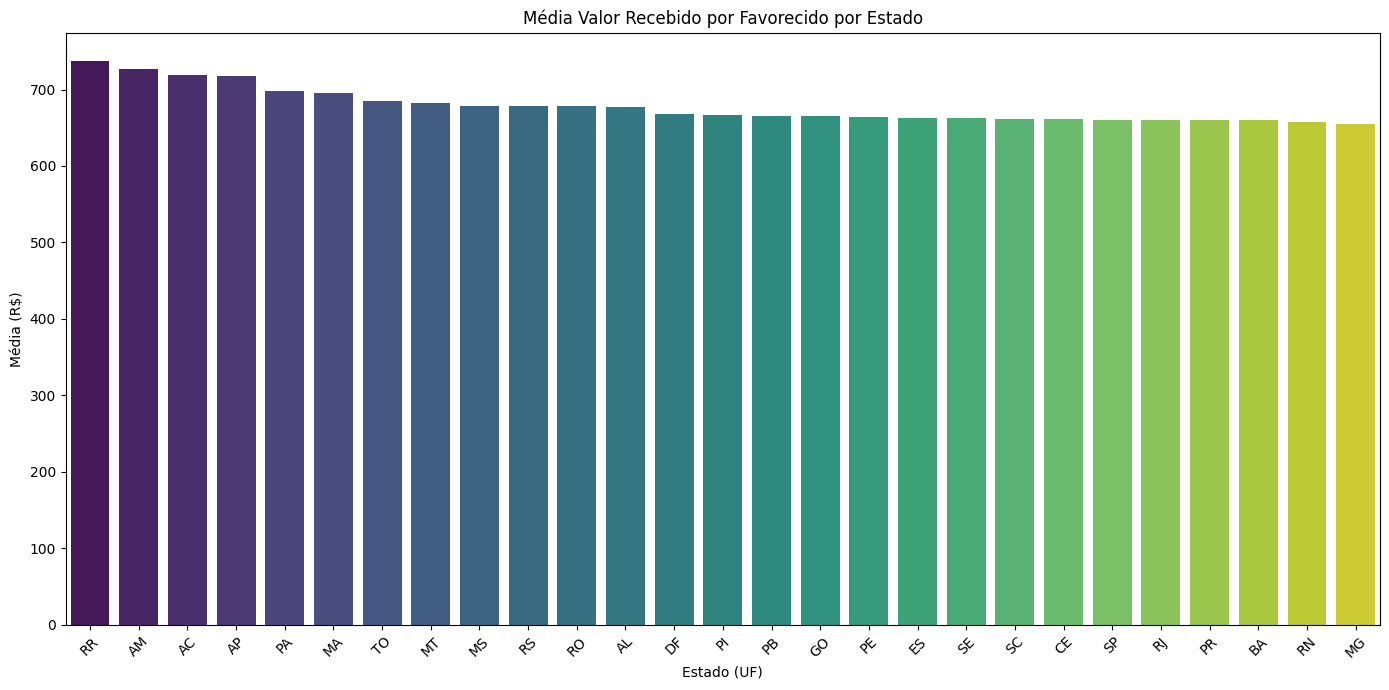

C:\Users\Win\AppData\Local\Temp\ipykernel_23324\1483843869.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


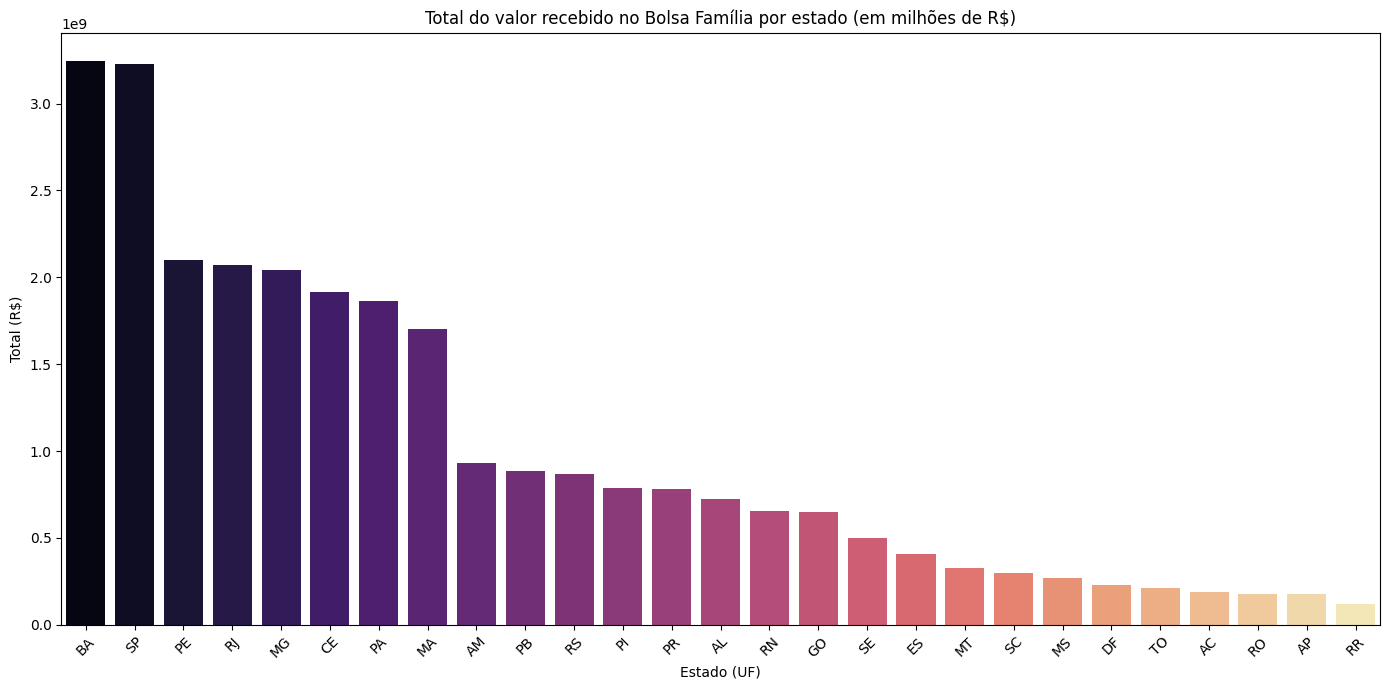

In [ ]:
# Vamos garantir que 'total_estado' volte a ser float para o gráfico
# Tinha convertido pra string com 'mi', vamos desfazer para o gráfico

df_estados = df_estados.with_columns([
    (pl.col('total_estado').str.replace(' mi', '').cast(pl.Float64) * 1_000_000).alias('total_estado_num')
])

plt.figure(figsize=(14,7))

#gráfico pela média por estado

sns.barplot(
    data=df_estados.sort('media_estado', descending=True).to_pandas(),
    x='uf',
    y='media_estado',
    palette='viridis'
)
plt.title('Média Valor Recebido por Favorecido por Estado')
plt.xlabel('Estado (UF)')
plt.ylabel('Média (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Gráfico do total por estado

plt.figure(figsize=(14, 7))
sns.barplot(
    data=df_estados.sort("total_estado_num", descending=True).to_pandas(),
    x="uf",
    y="total_estado_num",
    palette="magma"
)
plt.title("Total do valor recebido no Bolsa Família por estado (em milhões de R$)")
plt.xlabel("Estado (UF)")
plt.ylabel("Total (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

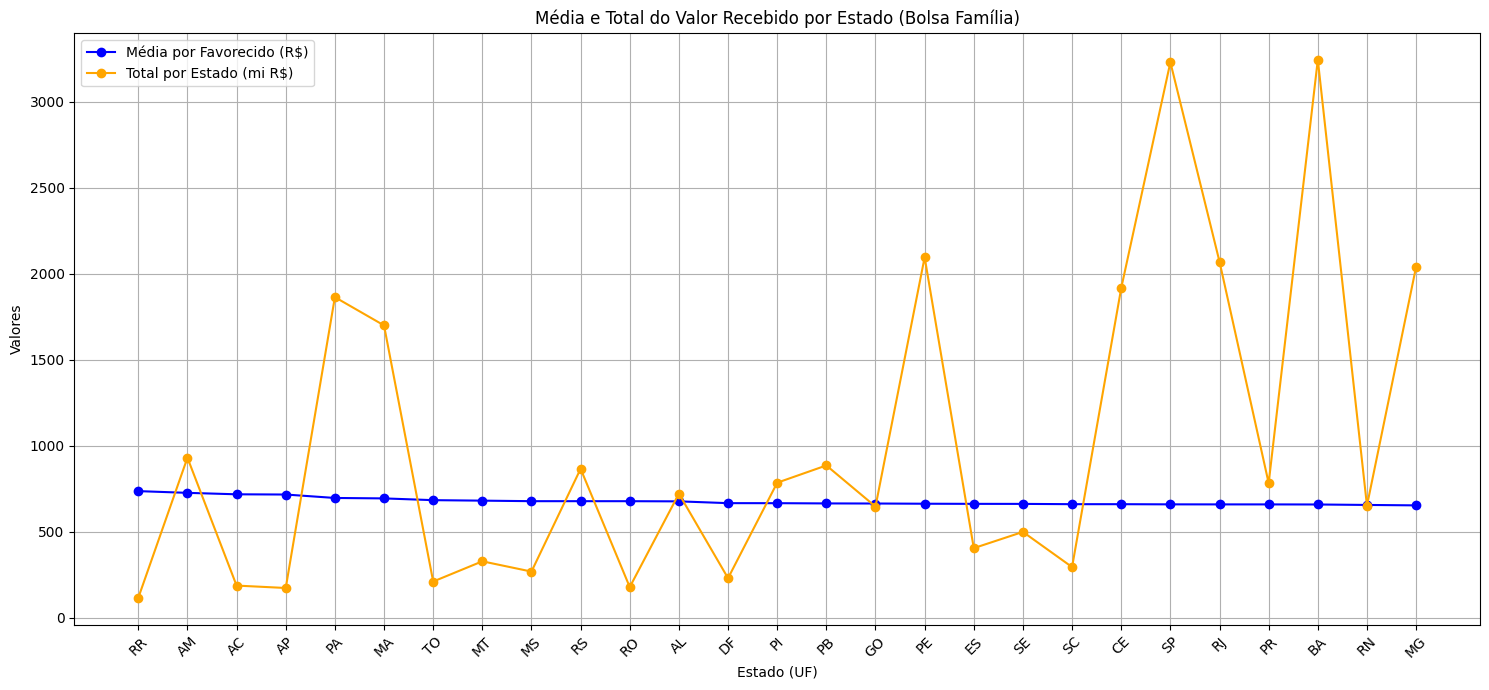

In [47]:
# Ordena pela média em ordem decrescente e converte para pandas
df_plot = df_estados.sort("media_estado", descending=True).to_pandas()

plt.figure(figsize=(15, 7))

plt.plot(df_plot["uf"], df_plot["media_estado"], marker='o', label="Média por Favorecido (R$)", color="blue")

plt.plot(df_plot["uf"], df_plot["total_estado_num"] / 1_000_000, marker='o', label="Total por Estado (mi R$)", color="orange")

plt.title("Média e Total do Valor Recebido por Estado (Bolsa Família)")
plt.xlabel("Estado (UF)")
plt.ylabel("Valores")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()